# Tugas_Pertemuan1

## Bussines Understanding

**Indeks Kualitas Udara (Air Quality Index / AQI)** adalah metrik pengukuran standar yang digunakan untuk menilai dan mengomunikasikan tingkat keparahan polusi udara di suatu wilayah kepada masyarakat umum. Nilai AQI bekerja layaknya termometer; semakin tinggi angkanya, semakin buruk kualitas udaranya dan semakin besar risiko dampaknya terhadap kesehatan manusia serta lingkungan sekitar.

**Unsur-Unsur Polutan Kualitas Udara:**
Kondisi kualitas udara sangat bergantung pada konsentrasi gas dan partikel berbahaya di atmosfer. Berdasarkan data satelit yang diamati dalam studi ini, lima unsur polutan utama yang menjadi parameter pengukuran meliputi:

*   **NO2 (Nitrogen Dioksida):** Gas beracun dan reaktif yang sebagian besar bersumber dari emisi gas buang kendaraan bermotor dan pembakaran bahan bakar fosil.
*   **CO (Karbon Monoksida):** Gas tidak berwarna dan tidak berbau yang dihasilkan dari proses pembakaran tidak sempurna. Gas ini sangat berbahaya jika terhirup karena dapat menghambat suplai oksigen dalam sirkulasi darah.
*   **SO2 (Sulfur Dioksida):** Gas berbau menyengat yang umumnya berasal dari pembakaran batu bara, aktivitas industri, atau fenomena vulkanik. Gas ini merupakan pemicu utama terjadinya hujan asam.
*   **O3 (Ozon Permukaan):** Berbeda dengan lapisan ozon di atmosfer atas yang melindungi bumi, ozon di permukaan tanah adalah polutan sekunder yang terbentuk dari reaksi kimia polutan lain (seperti NO2 dan emisi industri) dengan sinar matahari.
*   **HCHO (Formaldehida):** Senyawa organik yang mudah menguap (VOC) yang keberadaannya di udara mengindikasikan tingginya aktivitas industri, pembakaran biomassa, atau polusi fotokimia.

## Data Understanding

### Mengumpulkan Data Udara dari Copernicus Data Space
    
Data kualitas udara dalam analisis ini diekstraksi dari satelit **Sentinel-5P** melalui layanan antarmuka pemrograman **openEO** pada Copernicus Data Space Ecosystem. Pengambilan data difokuskan pada pengamatan kualitas udara di wilayah Bangkalan, Madura—yang mencakup area sekitar kampus Universitas Trunojoyo Madura—dengan rincian ekstraksi sebagai berikut:

*   **Rentang Waktu:** 24 Agustus 2025 s.d. 24 Agustus 2026.
*   **Batas Wilayah (Bounding Box):** Menggunakan parameter poligon spasial dengan batas Barat: `114.39276`, Selatan: `-5.5897084`, Timur: `114.4538978`, dan Utara: `-5.5323937`.
*   **Parameter Pengambilan:** Pengambilan data dilakukan secara iteratif untuk 5 *bands* polutan (NO2, CO, SO2, O3, HCHO) guna menghindari limitasi sistem unduhan massal dari satelit.
*   **Metode Agregasi:** Data mentah diagregasi secara spasial (mengambil nilai rata-rata dari seluruh titik piksel di dalam poligon wilayah) dan secara temporal (dijadikan rata-rata harian) agar menghasilkan tren observasi yang konsisten.

In [1]:
print("Kernel jalan!")

Kernel jalan!


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Membuat Datacube menggunakan koordinat

In [4]:
aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"id": "aoi_1"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [114.39276, -5.5634872],
                        [114.3971417, -5.5711689],
                        [114.415093, -5.571846],
                        [114.4227172, -5.5897084],
                        [114.4362736, -5.5862047],
                        [114.44798, -5.5776159],
                        [114.4538978, -5.565637],
                        [114.452815, -5.5471518],
                        [114.4302995, -5.5441407],
                        [114.4070893, -5.5323937],
                        [114.3964722, -5.5414599],
                        [114.39276, -5.5634872]
                    ]
                ],
            },
        }
    ],
}

In [5]:
# Membuat datacube untuk 5 unsur polutan secara terpisah
unsur_polutan = ["NO2", "CO", "SO2", "O3", "HCHO"]
datacubes = {}

for polutan in unsur_polutan:
    datacubes[polutan] = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=["2025-08-24", "2026-08-24"],
        spatial_extent={"west": 114.39276, "south": -5.5897084, "east": 114.4538978, "north": -5.5323937},
        bands=[polutan],
    )

In [6]:
# Now aggregate by day to avoid having multiple data per day
# let's create a spatial aggregation to generate mean timeseries data
for polutan in unsur_polutan:
    datacubes[polutan] = datacubes[polutan].aggregate_temporal_period(reducer="mean", period="day")
    datacubes[polutan] = datacubes[polutan].aggregate_spatial(reducer="mean", geometries=aoi)

### Eksekusi Code

In [7]:
# Eksekusi antrean unduhan untuk masing-masing polutan
for polutan in unsur_polutan:
    print(f"Mengeksekusi unduhan {polutan}...")
    datacubes[polutan].execute_batch(
        title=f"Analisis {polutan}", 
        outputfile=f"kualitas_udara_{polutan}.nc"
    )

Mengeksekusi unduhan NO2...


0:00:00 Job 'j-260914004034419194f6bdef476f1847': send 'start'


0:00:05 Job 'j-260914004034419194f6bdef476f1847': queued (progress 0%)


0:00:11 Job 'j-260914004034419194f6bdef476f1847': queued (progress 0%)


0:00:18 Job 'j-260914004034419194f6bdef476f1847': queued (progress 0%)


0:00:26 Job 'j-260914004034419194f6bdef476f1847': queued (progress 0%)


### Eksplorasi Data
Tahapan eksplorasi ini berfokus pada analisis visual dan pembersihan data (Data Preprocessing), yang mencakup:
*   **Visualisasi Peta:** Memetakan lokasi titik koordinat kotak pengamatan menggunakan *library* Folium untuk verifikasi cakupan spasial.
*   **Visualisasi Grafik:** Data divalidasi dan dinormalisasi (Min-Max 0-1) lalu divisualisasikan dalam bentuk grafik garis (*line chart*) bertumpuk serta diagram balok berkelompok (*grouped bar chart*) rata-rata bulanan. Visualisasi ini bertujuan untuk melihat dan membandingkan fluktuasi kelima polutan yang memiliki skala pengukuran berbeda secara seimbang.
*   **Identifikasi Anomali:** Melakukan identifikasi *missing values* (data satelit harian yang kosong/NaN akibat tertutup awan) serta mendeteksi keberadaan *outliers* dan data *noise* yang mungkin dipengaruhi oleh kesalahan sensor satelit.
*   **Pembuatan Output:** Mengonversi data dari format mentah NetCDF (`.nc`) menjadi format tabel dan mengekspornya sebagai *file* `.csv` untuk kemudahan pemodelan di aplikasi data mining lebih lanjut.

### Lokasi Data
Data yang diambil berasal dari kepulauan masalembu yang berada di sumenep

<img src="../images/kepulauan.png" width="600px" height="600px">

In [9]:

import xarray as xr
import matplotlib.pyplot as plt

In [10]:
# load the results (memuat 5 file terpisah ke dalam dictionary)
unsur_polutan = ["NO2", "CO", "SO2", "O3", "HCHO"]
data_udara_dict = {}

for polutan in unsur_polutan:
    data_udara_dict[polutan] = xr.load_dataset(f"kualitas_udara_{polutan}.nc")

In [11]:
# Menghitung rolling mean 30 hari untuk masing-masing polutan
for polutan in unsur_polutan:
    data_udara_dict[polutan] = data_udara_dict[polutan].rolling(t=30).mean()

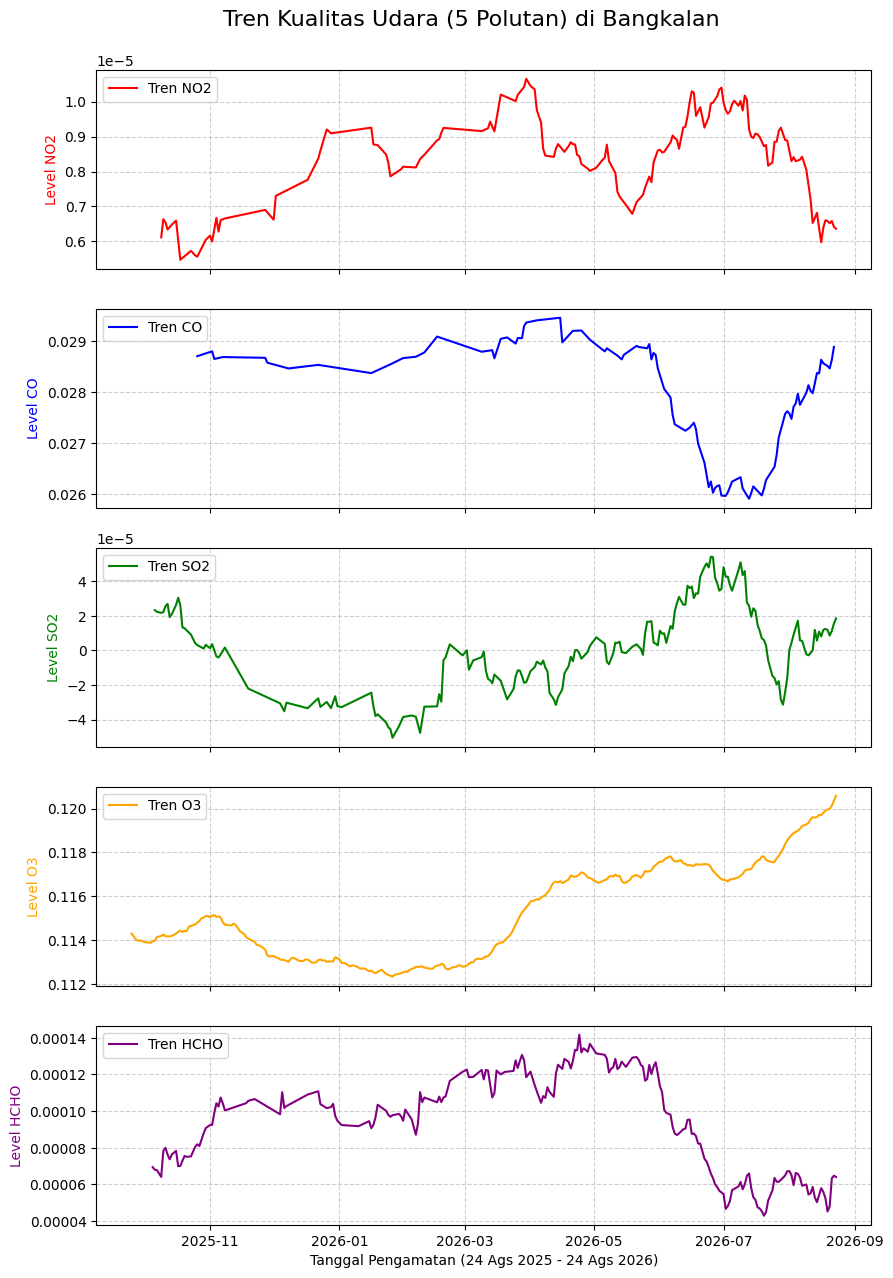

In [12]:
warna_grafik = ["red", "blue", "green", "orange", "purple"]

# Membuat layout 5 baris grafik
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 15), sharex=True)

for i, (polutan, warna) in enumerate(zip(unsur_polutan, warna_grafik)):
    # Mengambil data spesifik dari dictionary
    data_udara = data_udara_dict[polutan]
    
    axes[i].plot(data_udara.t, data_udara[polutan].to_numpy().flatten(), color=warna, label=f"Tren {polutan}")
    axes[i].set_ylabel(f"Level {polutan}", color=warna)
    axes[i].legend(loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Tanggal Pengamatan (24 Ags 2025 - 24 Ags 2026)")
plt.suptitle("Tren Kualitas Udara (5 Polutan) di Bangkalan", fontsize=16, y=0.92)

# Ekspor grafik menjadi gambar agar bisa dimasukkan ke catatan
plt.savefig("grafik_5_polutan.png", bbox_inches="tight")
plt.show()

In [13]:
import numpy as np

print("=== ANALISIS KUANTITAS DATA PER POLUTAN ===")
total_keseluruhan_data = 0

for polutan in unsur_polutan:
    # 1. Mengambil array nilai asli dari xarray polutan terkait
    nilai_asli = data_udara_dict[polutan][polutan].to_numpy().flatten()
    
    # 2. Hitung jumlah data point, data kosong, dan data valid
    jumlah_data = len(nilai_asli)
    jumlah_kosong = np.isnan(nilai_asli).sum()
    jumlah_valid = jumlah_data - jumlah_kosong
    
    # Akumulasi untuk total keseluruhan
    total_keseluruhan_data += jumlah_data
    
    # 3. Tampilkan hasil per polutan
    print(f"\nPolutan: {polutan}")
    print(f"  - Jumlah Data Tersedia : {jumlah_data} hari")
    print(f"  - Data Kosong (NaN)    : {jumlah_kosong} hari")
    print(f"  - Data Valid (Ada Isi) : {jumlah_valid} hari")

print(f"TOTAL KESELURUHAN DATA POINT: {total_keseluruhan_data} data")


=== ANALISIS KUANTITAS DATA PER POLUTAN ===

Polutan: NO2
  - Jumlah Data Tersedia : 186 hari
  - Data Kosong (NaN)    : 29 hari
  - Data Valid (Ada Isi) : 157 hari

Polutan: CO
  - Jumlah Data Tersedia : 127 hari
  - Data Kosong (NaN)    : 29 hari
  - Data Valid (Ada Isi) : 98 hari

Polutan: SO2
  - Jumlah Data Tersedia : 226 hari
  - Data Kosong (NaN)    : 29 hari
  - Data Valid (Ada Isi) : 197 hari

Polutan: O3
  - Jumlah Data Tersedia : 339 hari
  - Data Kosong (NaN)    : 29 hari
  - Data Valid (Ada Isi) : 310 hari

Polutan: HCHO
  - Jumlah Data Tersedia : 245 hari
  - Data Kosong (NaN)    : 29 hari
  - Data Valid (Ada Isi) : 216 hari
TOTAL KESELURUHAN DATA POINT: 1123 data


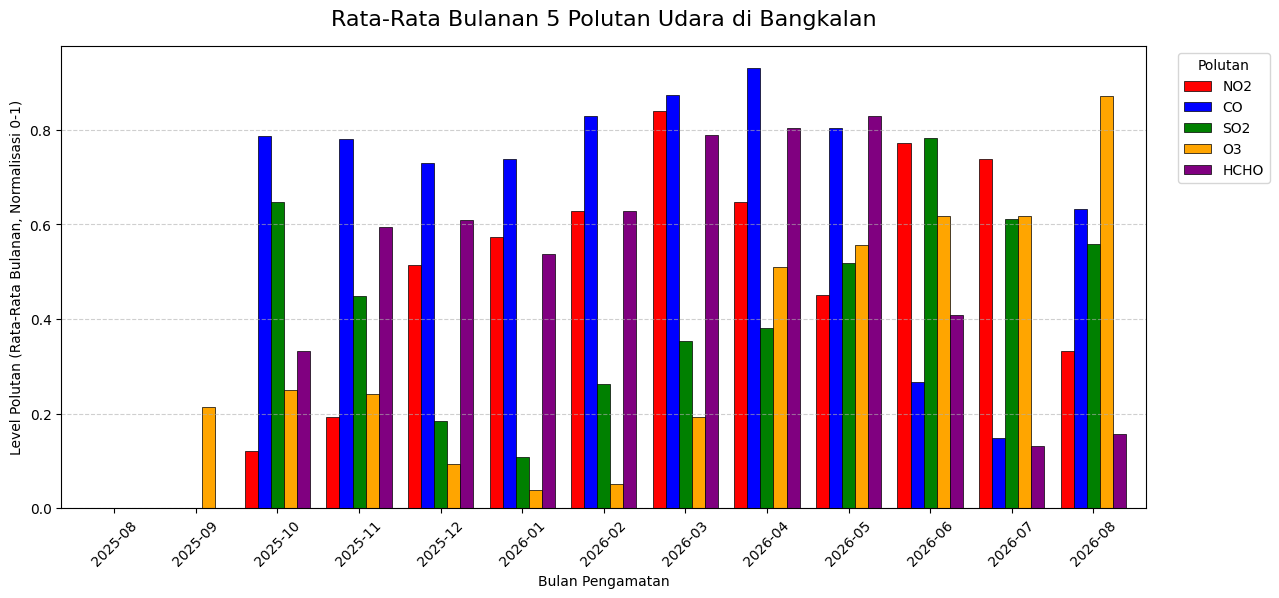

In [14]:
import pandas as pd
import numpy as np

# Membuat DataFrame kosong untuk menampung rata-rata bulanan
df_bulanan = pd.DataFrame()

for polutan in unsur_polutan:
    # Mengambil nilai waktu dan nilai polutan dari xarray
    waktu = data_udara_dict[polutan].t.values
    nilai_asli = data_udara_dict[polutan][polutan].to_numpy().flatten()
    
    # Normalisasi Min-Max (0 sampai 1)
    nilai_norm = (nilai_asli - np.nanmin(nilai_asli)) / (np.nanmax(nilai_asli) - np.nanmin(nilai_asli))
    
    # Memasukkan ke DataFrame Pandas sementara untuk diolah
    df_temp = pd.DataFrame({'Waktu': waktu, polutan: nilai_norm})
    
    # Ekstrak Tahun dan Bulan (Contoh format: 2025-08)
    df_temp['Bulan'] = pd.to_datetime(df_temp['Waktu']).dt.to_period('M')
    
    # Hitung rata-rata per bulan dan gabungkan
    rata2_bulanan = df_temp.groupby('Bulan')[polutan].mean()
    df_bulanan[polutan] = rata2_bulanan

# Mengubah format indeks bulan menjadi teks agar rapi di sumbu X
df_bulanan.index = df_bulanan.index.astype(str)

# Plotting Diagram Balok Berkelompok
ax = df_bulanan.plot(kind='bar', figsize=(14, 6), color=warna_grafik, width=0.8, edgecolor='black', linewidth=0.5)

# Pengaturan visualisasi sumbu dan label
ax.set_ylabel("Level Polutan (Rata-Rata Bulanan, Normalisasi 0-1)")
ax.set_xlabel("Bulan Pengamatan")
ax.legend(loc="upper right", bbox_to_anchor=(1.12, 1), title="Polutan")
ax.grid(axis='y', linestyle="--", alpha=0.6)
plt.xticks(rotation=45)

plt.title("Rata-Rata Bulanan 5 Polutan Udara di Bangkalan", fontsize=16, pad=15)

# Ekspor grafik menjadi gambar
plt.savefig("grafik_balok_bulanan.png", bbox_inches="tight")
plt.show()

In [15]:
import pandas as pd
import xarray as xr

unsur_polutan = ["NO2", "CO", "SO2", "O3", "HCHO"]
list_df = []

for polutan in unsur_polutan:
    # Membaca file NetCDF
    data = xr.load_dataset(f"kualitas_udara_{polutan}.nc")
    
    # Konversi data xarray menjadi DataFrame Pandas
    # reset_index() digunakan untuk memunculkan koordinat waktu 't' menjadi kolom
    df_temp = data[polutan].to_dataframe().reset_index()
    
    # Memfilter hanya mengambil kolom waktu ('t') dan kolom nilai polutannya
    df_temp = df_temp[['t', polutan]]
    
    # Mengatur kolom 't' sebagai Index agar penggabungan tabel berpatokan pada tanggal
    df_temp.set_index('t', inplace=True)
    list_df.append(df_temp)

# Menggabungkan semua tabel polutan berdasarkan tanggal (axis=1 menggabung ke samping)
df_gabungan = pd.concat(list_df, axis=1)

# Mengembalikan index tanggal menjadi kolom biasa dan mengganti namanya
df_gabungan.reset_index(inplace=True)
df_gabungan.rename(columns={'index': 'tanggal', 't': 'tanggal'}, inplace=True)

# Format kolom tanggal menjadi YYYY-MM-DD agar mudah dibaca PostgreSQL
df_gabungan['tanggal'] = pd.to_datetime(df_gabungan['tanggal']).dt.date

# Menyimpan hasil ke format CSV
df_gabungan.to_csv("data_kualitas_udara.csv", index=False)